<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/exercices_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Agregando Librerias

In [1]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=4d552ad0e80c0825de039611877b397903bdc68deaf6f9346c2ba40a855049c3
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


# Librerias

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS
from ISLP.bart import BART

from sklearn.tree import (DecisionTreeRegressor,
                          plot_tree,
                          DecisionTreeClassifier,
                          export_text)

from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor)

import sklearn.linear_model as skl

import sklearn.model_selection as skm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



Vamos a desarrollar la parte practica

# 7

In [ ]:
boston = load_data("Boston")

In [ ]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


En este dataset, tenemos que aplicar Random Forest con determinadas configuraciones, la variable respuesta es *medv*

In [ ]:
# vamos a hacer los primeros seteos con el modelo
model = MS(boston.columns.drop("medv"))
D = model.fit_transform(boston)

feature_names = list(D.columns)

X = np.asarray(D)


In [ ]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        boston['medv'],
                                                        test_size=.3,
                                                        random_state=42)

In [ ]:
boston_rf = RandomForestRegressor(max_features=6, n_estimators=100).fit(X_train, y_train)
y_hat_rf = boston_rf.predict(X_test)
np.mean((y_test - y_hat_rf)**2)


np.float64(9.68399655921053)

Necesitamos hacer un grafico en el que mostramos la evoluacion del MSE respecto de variaciones en los parametros. Especificamente la cantidad de features y los n_estimators.

In [ ]:
# haremos un gridsearch
params = {"n_estimators": [50, 100, 200 ,300 ,400 , 500],
          "max_features": np.arange(1, X_train.shape[1], 2)}

boston_rf = RandomForestRegressor(max_features=6,
                                  n_estimators=100,
                                  random_state=42)
kfold = skm.KFold(5,
                  random_state=42,
                  shuffle=True)
grid = skm.GridSearchCV(boston_rf,
                        param_grid=params,
                        scoring="neg_mean_squared_error",
                        n_jobs=-1,
                        verbose=2)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)





Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_features': np.int64(5), 'n_estimators': 50}
-12.867244527806843


In [ ]:
results = pd.DataFrame(grid.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.147545,0.013876,0.011213,0.000524,1,50,"{'max_features': 1, 'n_estimators': 50}",-18.600030,-18.579454,-26.931981,-12.937813,-22.010979,-19.812051,4.599394,36
1,0.267375,0.005234,0.018335,0.000077,1,100,"{'max_features': 1, 'n_estimators': 100}",-15.901557,-16.530594,-25.377569,-11.995456,-21.295476,-18.220130,4.640336,35
2,0.562506,0.009543,0.038322,0.003717,1,200,"{'max_features': 1, 'n_estimators': 200}",-15.466094,-15.599550,-25.593289,-11.865030,-21.027403,-17.910273,4.829154,32
3,0.832740,0.013429,0.052416,0.001483,1,300,"{'max_features': 1, 'n_estimators': 300}",-15.894542,-15.077325,-26.096178,-12.512424,-21.110799,-18.138254,4.862470,34
4,1.275567,0.292233,0.084977,0.024162,1,400,"{'max_features': 1, 'n_estimators': 400}",-15.608374,-14.947483,-26.062199,-12.644868,-20.963633,-18.045311,4.847413,33


In [ ]:
results = results[["param_max_features", "param_n_estimators", "mean_test_score"]]
results.head()

,param_max_features,param_n_estimators,mean_test_score
0,1,50,-19.812051
1,1,100,-18.220130
2,1,200,-17.910273
3,1,300,-18.138254
4,1,400,-18.045311


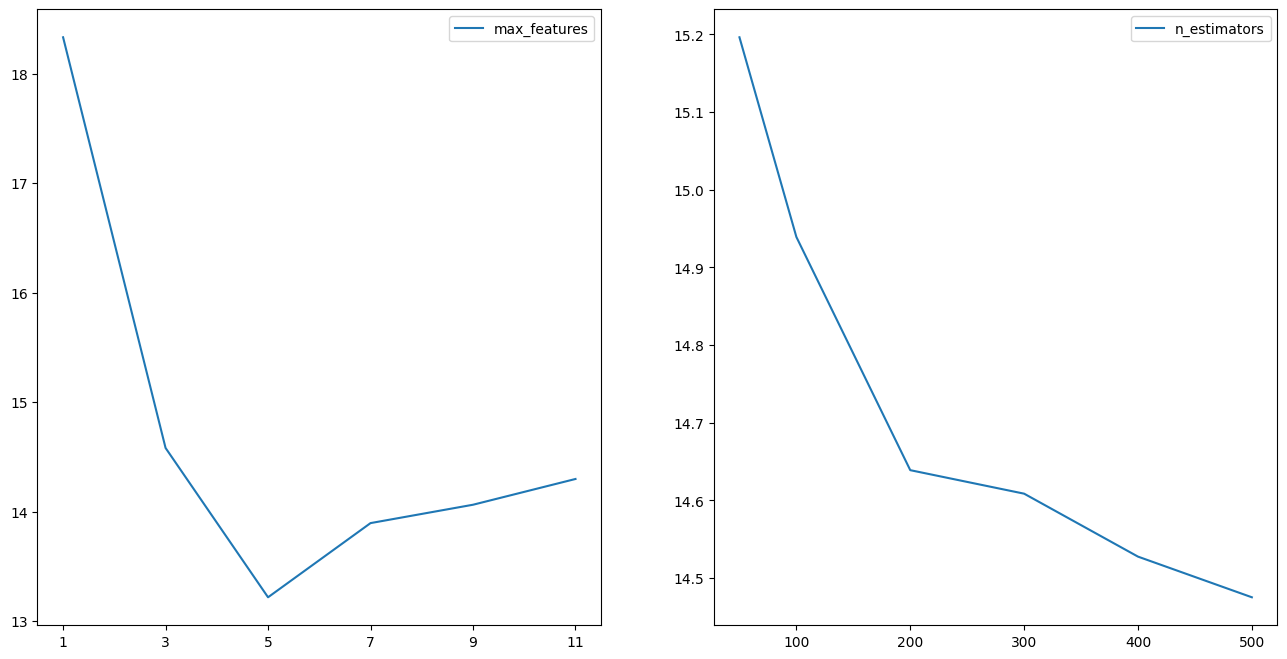

In [ ]:
# vamos a graficar
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
data_features = results.groupby("param_max_features").mean()
ax[0].plot([str(i) for i in data_features.index], -data_features["mean_test_score"], label="max_features")
ax[0].legend()
data_estimators = results.groupby("param_n_estimators")["mean_test_score"].mean()
ax[1].plot(data_estimators.index, -data_estimators, label="n_estimators")
ax[1].legend()
plt.show()

In [ ]:
data_estimators = results.groupby("param_n_estimators")["mean_test_score"].mean()
data_estimators

,mean_test_score
param_n_estimators,
50,-15.112885
100,-14.720715
200,-14.431915
300,-14.341900
400,-14.254070
500,-14.220134


In [ ]:
test_m_features = {}
max_n_estimators = 250

for max_feature in range(1, X_train.shape[1] + 1):
    test_m_features[max_feature] = []

    rf = RandomForestRegressor(n_estimators=1,
                               max_features=max_feature,
                               warm_start=True,
                               random_state=42)

    for estimator in range(1, max_n_estimators + 1):
        rf.n_estimators = estimator

        rf.fit(X_train, y_train)

        error = np.mean((y_test - rf.predict(X_test))**2)
        test_m_features[max_feature].append(error)

print("¡Terminado mucho más rápido!")

¡Terminado mucho más rápido!


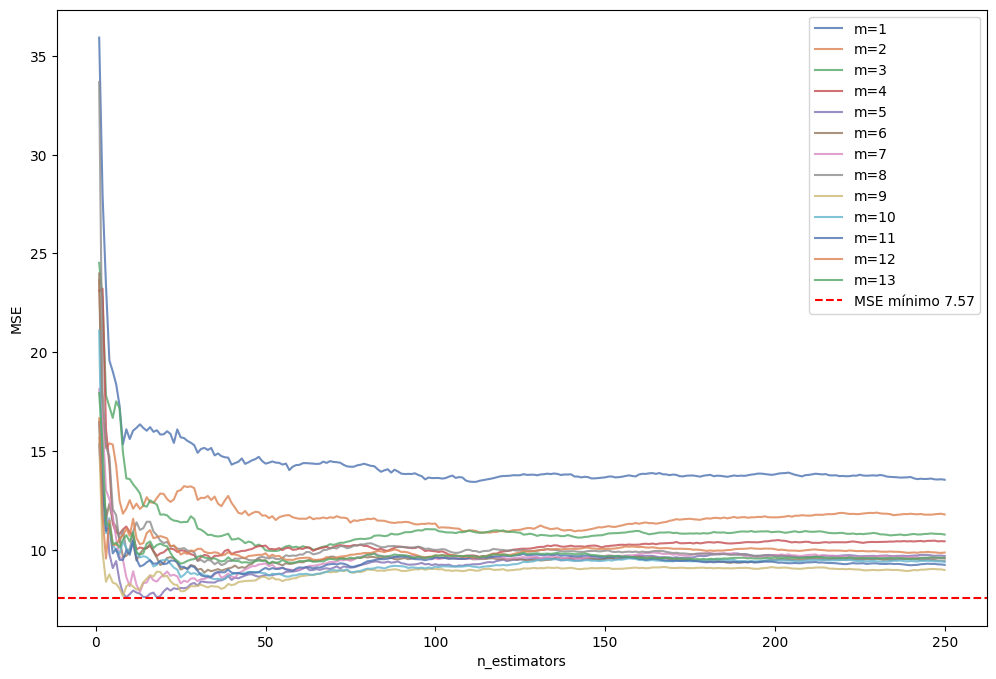

In [ ]:
# ahora vamos a graficar
fig, ax = plt.subplots(figsize=(12,8))
palette = sns.color_palette("deep", len(test_m_features))

for key, value in test_m_features.items():
  sns.lineplot(x=np.arange(1, max_n_estimators + 1),
               y=value,
               label=f"m={key}",
               ax=ax,
               color=palette[key - 1],
               alpha=0.8)
min_mse = min([min(value) for value in test_m_features.values()])
ax.axhline(y=min_mse,
           color="red",
           linestyle="--",
           label=f"MSE mínimo {min_mse.round(2)}")
ax.legend()
ax.set_xlabel("n_estimators")
ax.set_ylabel("MSE")
plt.show()

Podemos apreciar que en la busqueda, el cambio de max_features hasta un valor de 5 representa una gran caida en el mse del modelo. El valor minimo de MSE obtenido fue con la configuracion de 5 como max_features y 25 de n_estimators.

# 8

Vamos a usar el data set Carseats, con un configuracion cuantitativa de la variable respuesta.


In [ ]:
carseats = load_data("Carseats")
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## a)

In [ ]:
# vamos a splitear la informacion
model = MS(carseats.columns.drop("Sales"), intercept=False)
D = model.fit_transform(carseats)

feature_names = list(D.columns)

X_train, X_test, y_train, y_test = skm.train_test_split(D,
                                                        carseats["Sales"],
                                                        test_size=.3,
                                                        random_state=42)


## b)


In [ ]:
carseat_decision = DecisionTreeRegressor(max_depth=3,
                                          random_state=42).fit(X_train, y_train)

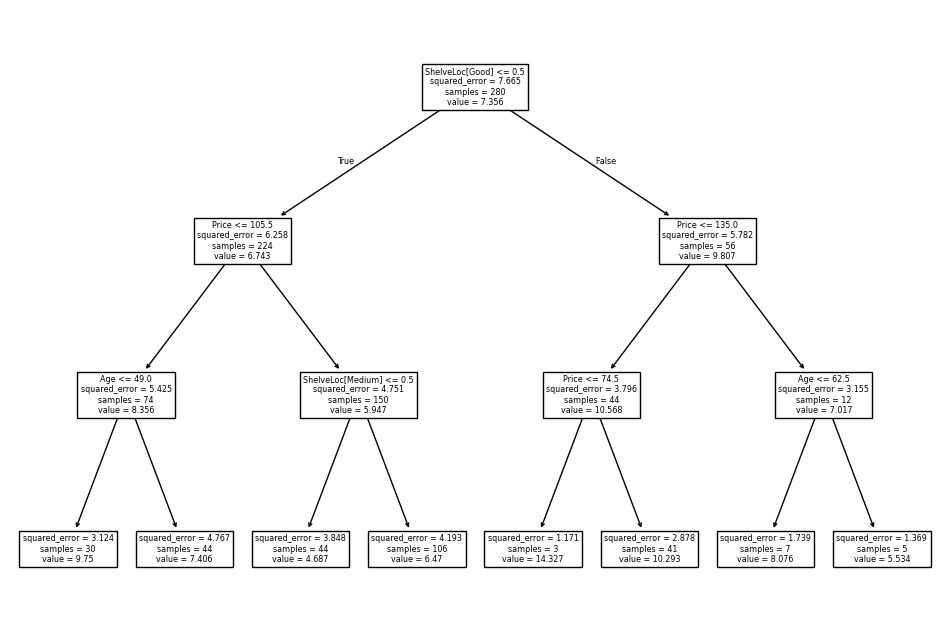

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
plot_tree(carseat_decision, feature_names=feature_names, ax=ax);



In [ ]:
y_hat_decision = carseat_decision.predict(X_test)
np.mean((y_test - y_hat_decision)**2)

np.float64(4.806952738698439)

Podemos apreciar que el modelo nos genera un arbol completo con los features, obteniendo un MSE de 4.80.

## c)

In [ ]:
# ahora vamos a buscar el max_depth de forma inteligente teniendo en cuenta el MSE
params = {"max_depth": np.arange(1, 25)}
kfold = skm.KFold(5,
                  random_state=42,
                  shuffle=True)
search = skm.GridSearchCV(DecisionTreeRegressor(random_state=42),
                          param_grid=params,
                          scoring="neg_mean_squared_error",
                          cv=kfold,
                          n_jobs=-1,
                          verbose=2,
                          )
search.fit(X_train, y_train)
search.best_params_
print(f"un modelo con max_depth={search.best_params_} logra un mse={-search.best_score_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
un modelo con max_depth={'max_depth': np.int64(7)} logra un mse=4.444171042588506


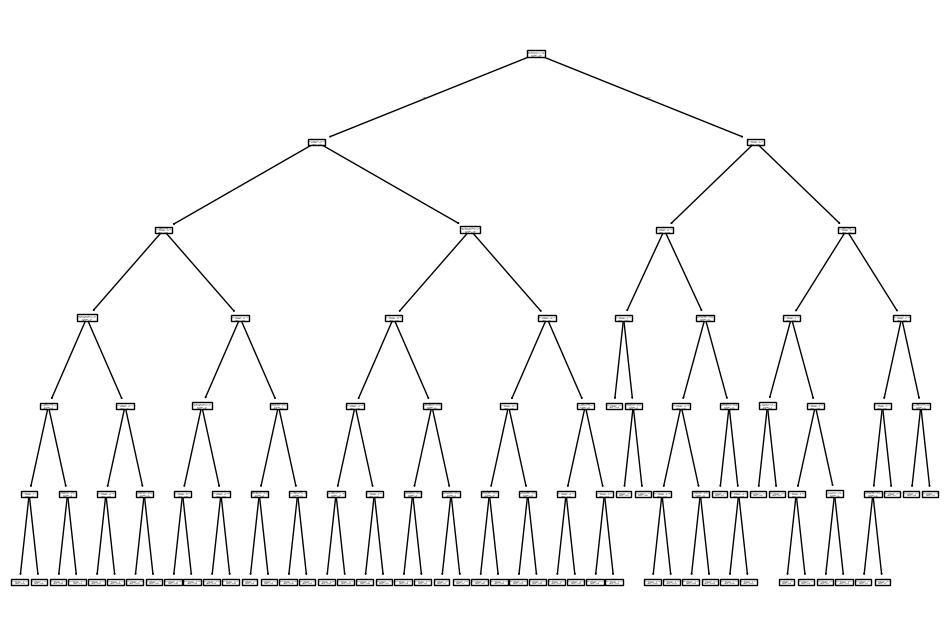

In [ ]:
carseat_decision = DecisionTreeRegressor(max_depth=6,
                                          random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(12,8))
plot_tree(carseat_decision, feature_names=feature_names, ax=ax);


In [ ]:
alphas_decision = carseat_decision.cost_complexity_pruning_path(X_train, y_train)

params = {"ccp_alpha": alphas_decision["ccp_alphas"]}

search = skm.GridSearchCV(carseat_decision,
                          param_grid=params,
                          scoring="neg_mean_squared_error",
                          cv=kfold
                          )
search.fit(X_train, y_train)
print(f"el modelo con un alpha de {search.best_estimator_} logra un mse de {search.best_score_}")

el modelo con un alpha de DecisionTreeRegressor(ccp_alpha=np.float64(0.039531624000999147), max_depth=6,
                      random_state=42) logra un mse de -4.257458041475013


Podemos apreciar que en el caso del mejor modelo con max_depth de 6, al aplicarle podammiento podemos lograr reducir el MSE, sin embargo la mejora no es tan significativa.

Veamos si es que el arbol necesita podamiento.


In [ ]:
decision = DecisionTreeRegressor(
                                random_state=42).fit(X_train, y_train)
alphas_decision = decision.cost_complexity_pruning_path(X_train, y_train)

# ahora hagamos la busqueda
params = {"ccp_alpha": alphas_decision["ccp_alphas"]}

search = skm.GridSearchCV(DecisionTreeRegressor(random_state=4),
                          param_grid=params,
                          scoring="neg_mean_squared_error",
                          cv=kfold
                          )
search.fit(X_train, y_train)
print(f"el modelo con un alpha de {search.best_estimator_} logra un mse de {search.best_score_}")

el modelo con un alpha de DecisionTreeRegressor(ccp_alpha=np.float64(0.05016071428571419), random_state=4) logra un mse de -4.21064054339231


Podemos apreciar que la estrategia con el podamiento logra tener un mse menor que el encontrado con una busqueda del mejor max_depth. Sin embargo, esta mejora no es tan significativa.

## d)

In [ ]:
# ahora vamos a desarrollar el bagging aproach
carseat_bagging = RandomForestRegressor(max_features=X_train.shape[1],
                                        random_state=42).fit(X_train, y_train)
y_hat_bagging = carseat_bagging.predict(X_test)
np.mean((y_test - y_hat_bagging)**2)

np.float64(2.534683515)

/tmp/ipython-input-3653987657.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


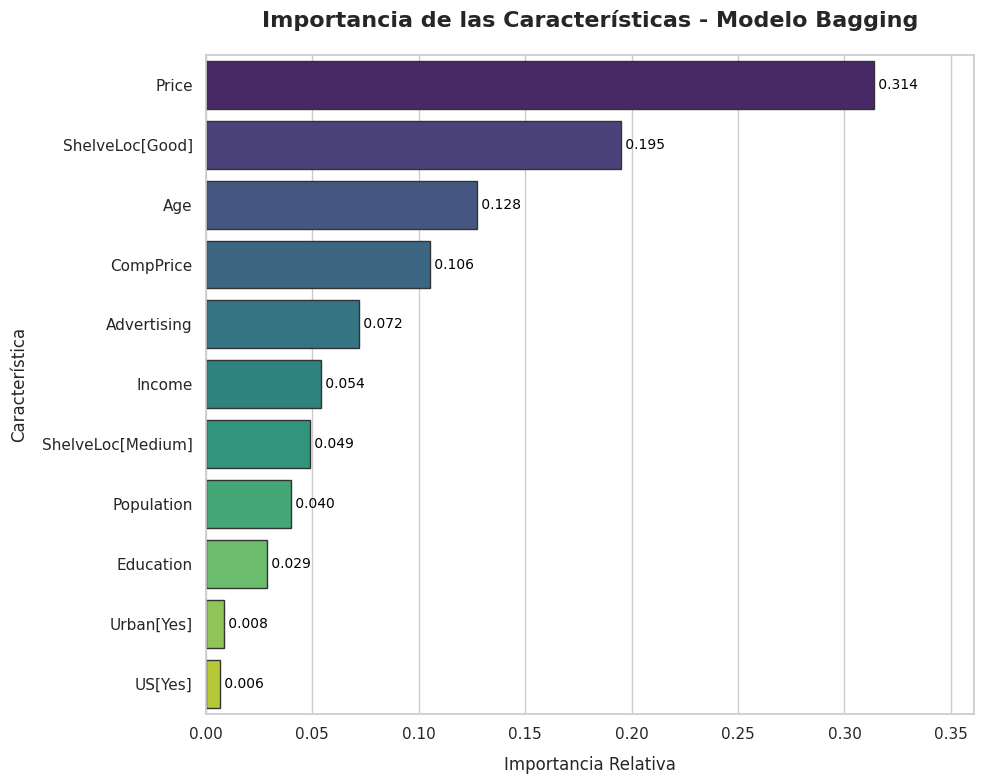

In [ ]:
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': carseat_bagging.feature_importances_
})

importances_df = importances_df.sort_values(by='Importance', ascending=False)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))


barplot = sns.barplot(
    data=importances_df,
    x='Importance', #
    y='Feature',
    palette='viridis',
    edgecolor='.2'
)


plt.title('Importancia de las Características - Modelo Bagging', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12, labelpad=10)
plt.ylabel('Característica', fontsize=12, labelpad=10)


for index, value in enumerate(importances_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center', ha='left', fontsize=10, color='black')

# Ajustamos el límite derecho del eje X para dar espacio al texto de los valores
plt.xlim(right=importances_df['Importance'].max() * 1.15)


plt.tight_layout()
plt.show()

Podemos apreciar que la variable mas importante es Price, la cual ha sido mas usada como corte en los arboles generados por random forest en configuracion de bagging

## e)

In [ ]:
# vamos a buscar la mejor configuracion de max_features

carseat_rf = RandomForestRegressor(random_state=42)

params = {"max_features": np.arange(1, X_train.shape[1] + 1)}

search = skm.GridSearchCV(carseat_rf,
                          param_grid=params,
                          cv=kfold,
                          scoring="neg_mean_squared_error")

search.fit(X_train, y_train)
print(f"con un configuracion de max_features={search.best_estimator_} tenemos un mse={search.best_score_}")

con un configuracion de max_features=RandomForestRegressor(max_features=np.int64(10), random_state=42) tenemos un mse=-2.614547239607141


In [ ]:
carseat_rf = RandomForestRegressor(max_features=10, random_state=42).fit(X_train, y_train)
y_hat_rf = carseat_rf.predict(X_test)
np.mean((y_test - y_hat_rf)**2)

np.float64(2.463991149833332)

/tmp/ipython-input-2641078235.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


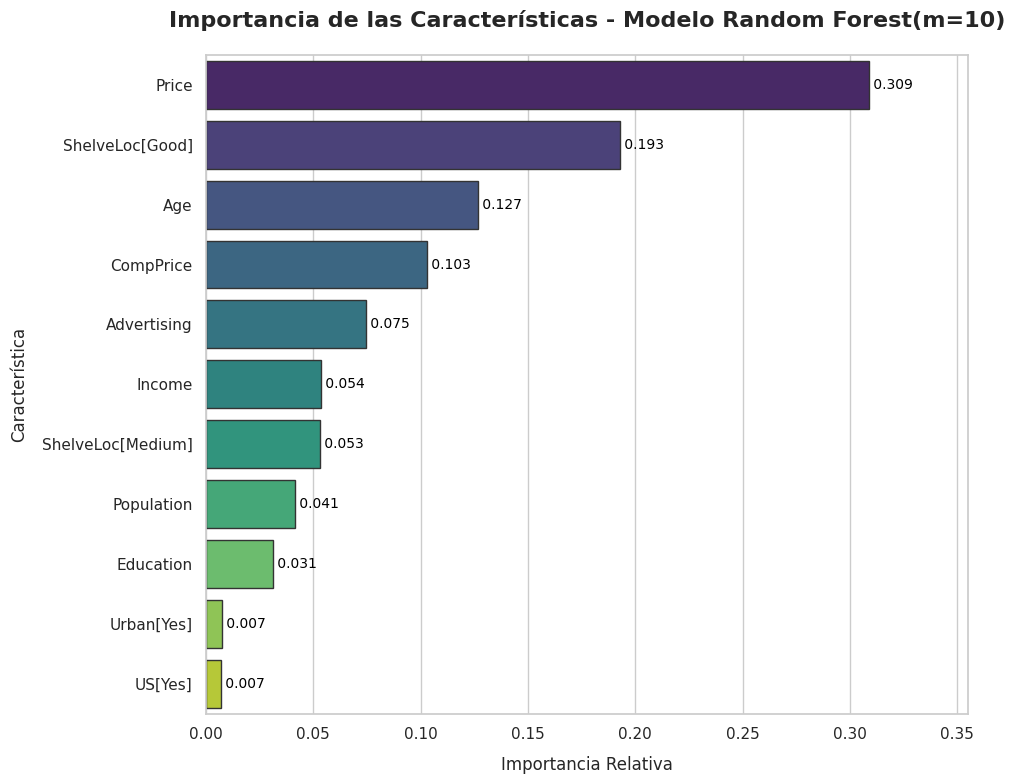

In [ ]:

importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': carseat_rf.feature_importances_
})

importances_df = importances_df.sort_values(by='Importance', ascending=False)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))


barplot = sns.barplot(
    data=importances_df,
    x='Importance', #
    y='Feature',
    palette='viridis',
    edgecolor='.2'
)


plt.title('Importancia de las Características - Modelo Random Forest(m=10)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12, labelpad=10)
plt.ylabel('Característica', fontsize=12, labelpad=10)


for index, value in enumerate(importances_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center', ha='left', fontsize=10, color='black')

# Ajustamos el límite derecho del eje X para dar espacio al texto de los valores
plt.xlim(right=importances_df['Importance'].max() * 1.15)


plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame(search.cv_results_)
results = results[["param_max_features", "mean_test_score"]]
results["mean_test_score"] = -results["mean_test_score"]

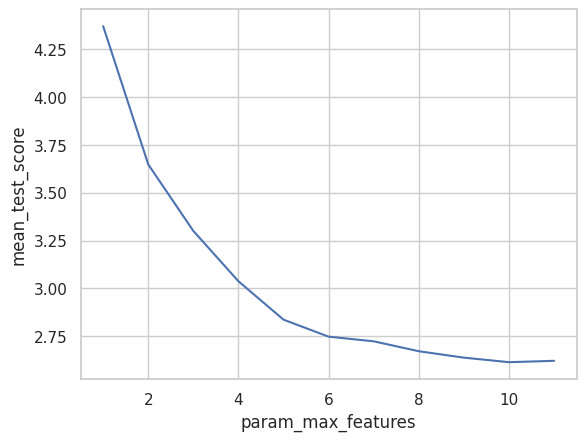

In [ ]:
sns.lineplot(data=results, x="param_max_features", y="mean_test_score")
plt.show()

Podemos apreciar que el Random Forest logra una reduccion grande hasta los 6 de max_features.

## f)

In [ ]:
carseat_bart = BART(burnin=100, ndraw=1000,
                    random_state=42).fit(X_train, y_train)
y_hat_bart = carseat_bart.predict(X_test)
np.mean((y_test - y_hat_bart)**2)

np.float64(1.2440141807904748)

# 9


Ahora vamos a trabajar sobre el data set OJ y tendremos como variable respuesta a Purchase.


In [3]:
oj = load_data("OJ")


In [4]:
oj.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [5]:
oj.describe()

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
count,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,254.381308,3.959813,1.867421,2.085411,0.051860,0.123364,0.147664,0.161682,0.565782,1.962047,1.815561,0.146486,0.059298,0.027314,0.217991,1.630841
std,15.558286,2.308984,0.101970,0.134386,0.117474,0.213834,0.354932,0.368331,0.307843,0.252697,0.143384,0.271563,0.101760,0.062232,0.107535,1.430387
min,227.000000,1.000000,1.690000,1.690000,0.000000,0.000000,0.000000,0.000000,0.000011,1.190000,1.390000,-0.670000,0.000000,0.000000,0.000000,0.000000
25%,240.000000,2.000000,1.790000,1.990000,0.000000,0.000000,0.000000,0.000000,0.325257,1.690000,1.750000,0.000000,0.000000,0.000000,0.140000,0.000000
50%,257.000000,3.000000,1.860000,2.090000,0.000000,0.000000,0.000000,0.000000,0.600000,2.090000,1.860000,0.230000,0.000000,0.000000,0.240000,2.000000
75%,268.000000,7.000000,1.990000,2.180000,0.000000,0.230000,0.000000,0.000000,0.850873,2.130000,1.890000,0.320000,0.112676,0.000000,0.300000,3.000000
max,278.000000,7.000000,2.090000,2.290000,0.500000,0.800000,1.000000,1.000000,0.999947,2.290000,2.090000,0.640000,0.402010,0.252688,0.440000,4.000000


In [6]:
oj.Purchase.value_counts()

,count
Purchase,
CH,653
MM,417


## a


In [7]:
# vamos a splitear la informacion
design = MS(oj.columns.drop("Purchase"), intercept=False)
D = design.fit_transform(oj)

feature_names = list(D.columns)

X = np.asarray(D)

X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        oj.Purchase,
                                                        train_size=800,
                                                        random_state=42)



In [8]:
D.head()

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7[Yes],PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,0.0,0.000000,0.000000,0.24,1
1,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,0.0,0.150754,0.000000,0.24,1
2,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,0.0,0.000000,0.091398,0.23,1
3,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,0.0,0.000000,0.000000,0.00,1
4,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,1.0,0.000000,0.000000,0.00,0


## b) Fit a tree to the training data, with Purchase as the response and the other variables as predictors. What is the training error rate?

In [9]:
# para esto necesitamos un deciscion classifier tree
decision_oj = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
y_hat_decision_train= decision_oj.predict(X_train)

np.mean(y_hat_decision_train != y_train)

np.float64(0.0075)

## c) Create a plot of the tree, and interpret the results. How many terminal nodes does the tree have?

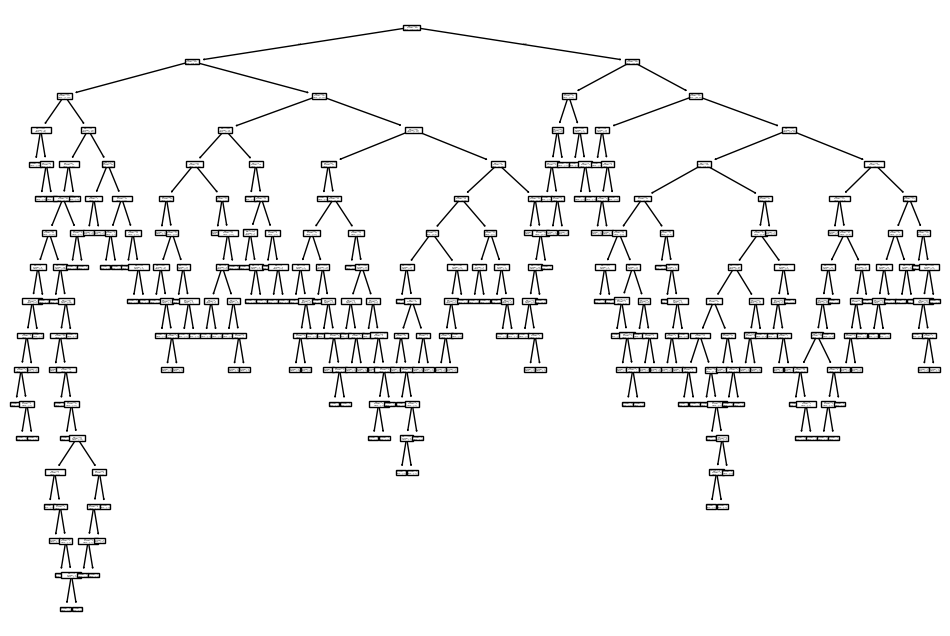

In [10]:
fig, ax = plt.subplots(figsize=(12,8))
plot_tree(decision_oj, feature_names=feature_names, ax=ax);

In [11]:
decision_oj.get_n_leaves()

np.int64(163)

Podemos apreciar que el arbol generado es bien amplio y que para el set de entrenamiento es muy bueno ya que tiene un error minimo, lo que nos podria indicar overfitting. En total tenemos 163 leaves.

## d) Use the export_tree() function to produce a text summary of the fitted tree. Pick one of the terminal nodes, and interpret the information displayed.

In [12]:
print(export_text(decision_oj, feature_names=feature_names))

|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- WeekofPurchase <= 268.50
|   |   |   |   |--- class: MM
|   |   |   |--- WeekofPurchase >  268.50
|   |   |   |   |--- PriceDiff <= 0.29
|   |   |   |   |   |--- class: MM
|   |   |   |   |--- PriceDiff >  0.29
|   |   |   |   |   |--- class: CH
|   |   |--- LoyalCH >  0.06
|   |   |   |--- LoyalCH <= 0.21
|   |   |   |   |--- WeekofPurchase <= 273.00
|   |   |   |   |   |--- WeekofPurchase <= 261.00
|   |   |   |   |   |   |--- PriceDiff <= -0.13
|   |   |   |   |   |   |   |--- SalePriceMM <= 1.64
|   |   |   |   |   |   |   |   |--- WeekofPurchase <= 236.50
|   |   |   |   |   |   |   |   |   |--- WeekofPurchase <= 234.00
|   |   |   |   |   |   |   |   |   |   |--- LoyalCH <= 0.16
|   |   |   |   |   |   |   |   |   |   |   |--- class: MM
|   |   |   |   |   |   |   |   |   |   |--- LoyalCH >  0.16
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |

Podemos apreciar que cada rama se desprende otro subarbol. Voy a elegir el siguiente:
Si es LoyalCh es <= .5 <= .28 <=0.06
y WeekofPurchase <= 268.5 entonces la clase sera MM

## (e) Predict the response on the test data, and produce a confusion matrix comparing the test labels to the predicted test labels. What is the test error rate?

In [13]:
y_hat_test = decision_oj.predict(X_test)
np.mean(y_hat_test != y_test)

np.float64(0.2777777777777778)

In [14]:
confusion_table(y_hat_test, y_test)

Truth,CH,MM
Predicted,,
CH,121,37
MM,38,74


In [15]:
(38 + 37) / X_test.shape[0]


0.2777777777777778

podemos apreciar que el error rate es del 28% aproximadamente, repartidos casi por igual entre los falsos predecidos.

## (f) Use cross-validation on the training set in order to determine the optimal tree size.


In [32]:
params = {"max_depth": np.arange(1, 21)}
kfold = skm.KFold(5,
                  random_state=42,
                  shuffle=True)
search = skm.GridSearchCV(DecisionTreeClassifier(random_state=42),
                          scoring="accuracy",
                          cv=kfold,
                          param_grid=params)
search.fit(X_train, y_train)
print(f"El mejor modelo tiene un max_depth={search.best_params_} con un accuracy={search.best_score_}")
print(f"el modelo tiene {search.best_estimator_.get_n_leaves()}")

El mejor modelo tiene un max_depth={'max_depth': np.int64(3)} con un accuracy=0.8125
el modelo tiene 8


## (g) Produce a plot with tree size on the x-axis and cross-validated classification error rate on the y-axis.

In [23]:

results = pd.DataFrame(search.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007471,0.002973,0.003449,0.000614,1,{'max_depth': 1},0.85000,0.83125,0.83750,0.71250,0.73750,0.79375,0.057009,5
1,0.005550,0.000045,0.003280,0.000060,2,{'max_depth': 2},0.85000,0.84375,0.83750,0.71250,0.76875,0.80250,0.053706,3
2,0.005781,0.000379,0.004137,0.002101,3,{'max_depth': 3},0.82500,0.85625,0.83125,0.78750,0.76250,0.81250,0.033307,1
3,0.005910,0.000132,0.003007,0.000144,4,{'max_depth': 4},0.81875,0.85625,0.81875,0.75625,0.76875,0.80375,0.036572,2
4,0.006426,0.000289,0.003089,0.000096,5,{'max_depth': 5},0.83750,0.83125,0.81250,0.73750,0.77500,0.79875,0.037583,4


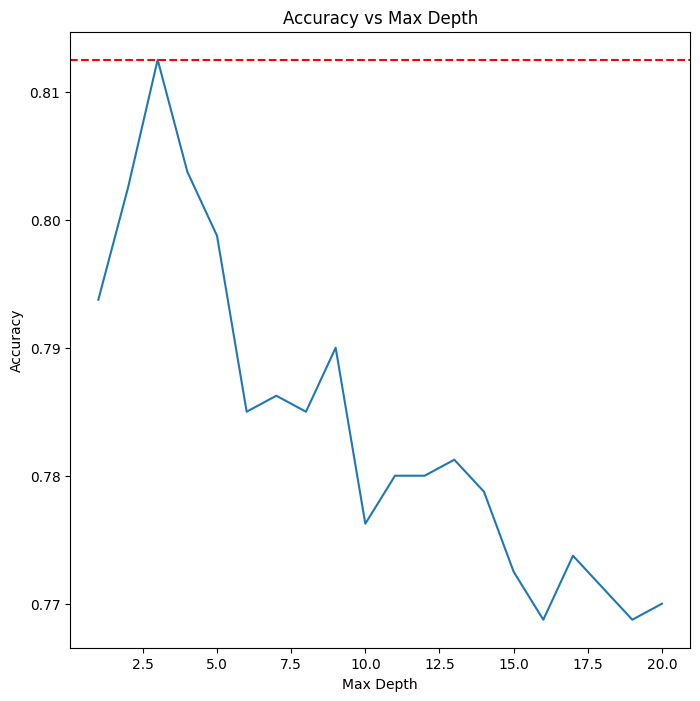

In [26]:
results = results[["param_max_depth", "mean_test_score"]]

fig, ax = plt.subplots(figsize=(8,8))
sns.lineplot(data=results, x="param_max_depth", y="mean_test_score", ax=ax)
ax.set_title("Accuracy vs Max Depth")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.axhline(results["mean_test_score"].max(), color="red", linestyle="--")

## (h) Which tree size corresponds to the lowest cross-validated classi-fication error rate?

Dada la busqueda de los hiperparametros usando GridSearchCV, obtenemos que el valor de max_depth es de 3 teniendo el mejor accuracy.

## (i) Produce a pruned tree corresponding to the optimal tree size obtained using cross-validation. If cross-validation does not lead to selection of a pruned tree, then create a pruned tree with five terminal nodes.

In [35]:
best_oj = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

alphas_decision = best_oj.cost_complexity_pruning_path(X_train, y_train)

param = {"ccp_alpha": alphas_decision["ccp_alphas"]}

search = skm.GridSearchCV(best_oj,
                          param_grid=param,
                          cv=kfold,
                          scoring="accuracy")
search.fit(X_train, y_train)
print(f"El mejor modelo tiene un valor de ccp_alpha:{search.best_params_} con un accuracy={search.best_score_}")
print(f"el modelo tendra en total leaves:{search.best_estimator_.get_n_leaves()}")

El mejor modelo tiene un valor de ccp_alpha:{'ccp_alpha': np.float64(0.006597346201628912)} con un accuracy=0.81375
el modelo tendra en total leaves:6


## (j) Compare the training error rates between the pruned and unpruned trees. Which is higher?

In [34]:
normal_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
y_hat_normal = normal_tree.predict(X_train)
np.mean(y_hat_normal != y_train)

np.float64(0.15375)

In [39]:
pruned_tree = DecisionTreeClassifier(ccp_alpha=search.best_params_["ccp_alpha"], random_state=42).fit(X_train, y_train)
y_hat_pruned = pruned_tree.predict(X_train)
np.mean(y_hat_pruned != y_train)

np.float64(0.15625)

Podemos apreciar que el Error de clasificacion entre ambos modelos es casi lo mismo. por muy poco el error del modelo sin podar es mejor, pero la diferencia no es relevante


## (k) Compare the test error rates between the pruned and unpruned trees. Which is higher?

In [40]:
y_hat_normal = normal_tree.predict(X_test)
np.mean(y_hat_normal != y_test)

np.float64(0.21481481481481482)

In [41]:
y_hat_pruned = pruned_tree.predict(X_test)
np.mean(y_hat_pruned != y_test)
#

np.float64(0.1925925925925926)

EN este caso podemos apreciar que existe un diferencia de 2 puntos porcentuales de que el modelo podado es mejor que el modelo normal.

# 10

In [51]:
hitters = load_data("Hitters")

In [43]:
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [44]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

## (a) Remove the observations for whom the salary information is unknown, and then log-transform the salaries

In [54]:
hitters.isna().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [53]:
hitters.dropna(axis=0, inplace=True)

In [55]:
hitters.Salary = np.log(hitters.Salary)

In [56]:
hitters.Salary

,Salary
1,6.163315
2,6.173786
3,6.214608
4,4.516339
5,6.620073
...,...
317,6.551080
318,6.774224
319,5.953243
320,6.866933


## (b) Create a training set consisting of the first 200 observations, and a test set consisting of the remaining observations.

In [62]:
X_test.shape

(63, 19)

In [64]:
design = MS(hitters.columns.drop("Salary"), intercept=False)

D = design.fit_transform(hitters)

feature_names = list(D.columns)

X = np.asarray(D)

X_train = X[:200, :]
X_test = X[200:, :]

y_train = hitters.Salary[:200]
y_test = hitters.Salary[200:]

## (c) Perform boosting on the training set with 1,000 trees for a range of values of the shrinkage parameter λ. Produce a plot  with different shrinkage values on the x-axis and the corresponding training set MSE on the y-axis

In [68]:
learning_rates = np.linspace(0.001, 0.2, 100)

train_mse = []
test_mse = []

for rate in learning_rates:
  boosting_tree = GradientBoostingRegressor(n_estimators=1000,
                                            learning_rate=rate,
                                            max_depth=1)
  boosting_tree.fit(X_train, y_train)

  y_hat_train = boosting_tree.predict(X_train)
  y_hat_test = boosting_tree.predict(X_test)

  train_mse.append(np.mean((y_train - y_hat_train)**2))
  test_mse.append(np.mean((y_test - y_hat_test)**2))

Text(0, 0.5, 'MSE')

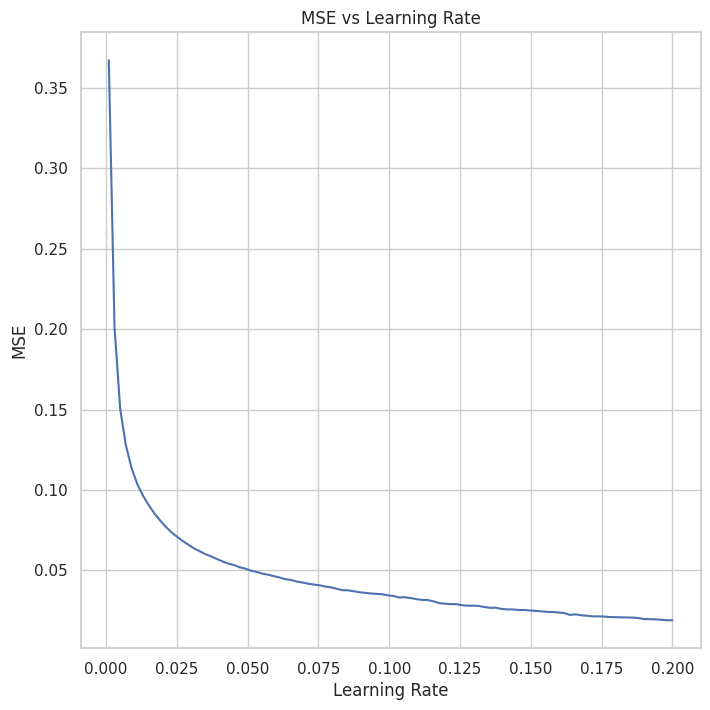

In [69]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8,8))
sns.lineplot(x=learning_rates, y=train_mse, ax=ax)
ax.set_title("MSE vs Learning Rate")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("MSE")

## (d) Produce a plot with different shrinkage values on the x-axis and the corresponding test set MSE on the y-axis.

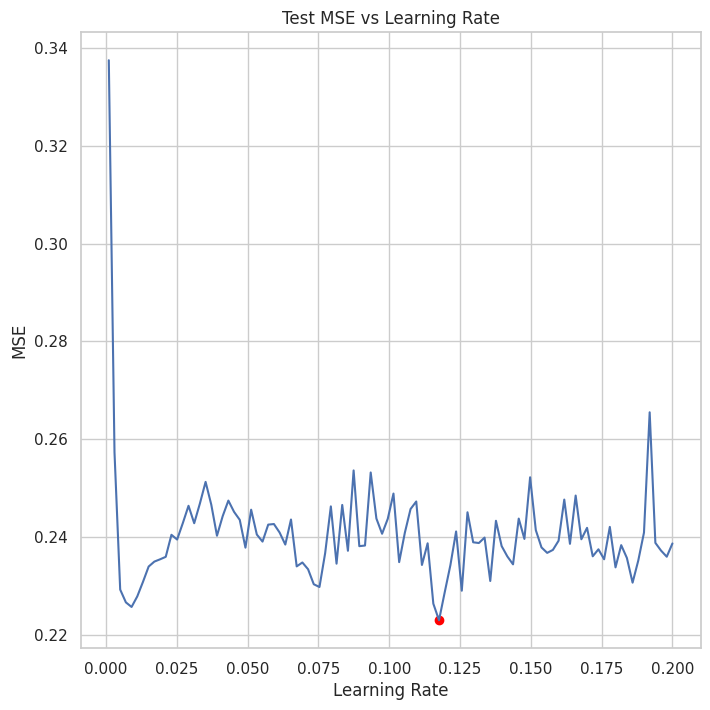

In [97]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8,8))
sns.lineplot(x=learning_rates, y=test_mse, ax=ax)
ax.scatter(learning_rates[np.argmin(test_mse)], min(test_mse), color="red")
ax.set_title("Test MSE vs Learning Rate")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("MSE")
boostin_mse = min(test_mse)
boostin_lambda = learning_rates[np.argmin(test_mse)]

## (e) Compare the test MSE of boosting to the test MSE that results from applying two of the regression approaches seen inChapters 3 and 6.

In [90]:
# Lasso
kfold = skm.KFold(5, shuffle=True,
                  random_state=42)

design = MS(hitters.columns.drop("Salary"))

D = design.fit_transform(hitters)
X_train = D.iloc[:200, :]
X_test = D.iloc[200:, :]

y_train = hitters.Salary[:200]
y_test = hitters.Salary[200:]

scaler = StandardScaler()

lambdas = np.logspace(-4, 4, 100)
pipe = Pipeline([("scaler", scaler),
                 ("lasso", skl.LassoCV(alphas=lambdas, cv=kfold, max_iter=10000))])

pipe.fit(X_train, y_train)

y_hat_lasso = pipe.predict(X_test)

lasso_mse = np.mean((y_test - y_hat_lasso)**2)

In [91]:
# ridge

lambdas = np.logspace(-4, 4, 100)
pipe = Pipeline([("scaler", scaler),
                 ("ridge", skl.RidgeCV(alphas=lambdas, cv=kfold))])

pipe.fit(X_train, y_train)

y_hat_ridge = pipe.predict(X_test)

ridge_mse = np.mean((y_test - y_hat_ridge)**2)

In [93]:
print(f"el modelo Lasso tiene un MSE de {lasso_mse}")
print(f"el modelo Ridge tiene un MSE de {ridge_mse}")
print(f"el modelo de boosting tiene un MSE de {boostin_mse}")

el modelo Lasso tiene un MSE de 0.4708580355282612
el modelo Ridge tiene un MSE de 0.4682630254771817
el modelo de boosting tiene un MSE de 0.22300655169528982


In [85]:
X_train

,intercept,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League[N],Division[W],PutOuts,Assists,Errors,NewLeague[N]
1,1.0,315,81,7,24,38,39,14,3449,835,69,321,414,375,1.0,1.0,632,43,10,1.0
2,1.0,479,130,18,66,72,76,3,1624,457,63,224,266,263,0.0,1.0,880,82,14,0.0
3,1.0,496,141,20,65,78,37,11,5628,1575,225,828,838,354,1.0,0.0,200,11,3,1.0
4,1.0,321,87,10,39,42,30,2,396,101,12,48,46,33,1.0,0.0,805,40,4,1.0
5,1.0,594,169,4,74,51,35,11,4408,1133,19,501,336,194,0.0,1.0,282,421,25,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,1.0,256,70,13,42,36,44,16,7058,1845,312,965,1128,990,1.0,0.0,41,118,8,0.0
244,1.0,466,108,33,75,86,72,3,652,142,44,102,109,102,0.0,0.0,286,8,8,0.0
245,1.0,327,68,13,42,29,45,18,3949,939,78,438,380,466,0.0,0.0,659,53,7,0.0
247,1.0,341,110,9,45,49,46,9,2331,658,50,249,322,274,0.0,0.0,251,9,4,0.0


## (f) Which variables appear to be the most important predictors in the boosted model?

In [106]:
design = MS(hitters.columns.drop("Salary"), intercept=False)

D = design.fit_transform(hitters)

feature_names = list(D.columns)

X = np.asarray(D)

X_train = X[:200, :]
X_test = X[200:, :]

y_train = hitters.Salary[:200]
y_test = hitters.Salary[200:]
boosted = GradientBoostingRegressor(n_estimators=1000,
                                    learning_rate=boostin_lambda,
                                    max_depth=1)
boosted.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=np.float64(0.11758585858585859),
                          max_depth=1, n_estimators=1000)

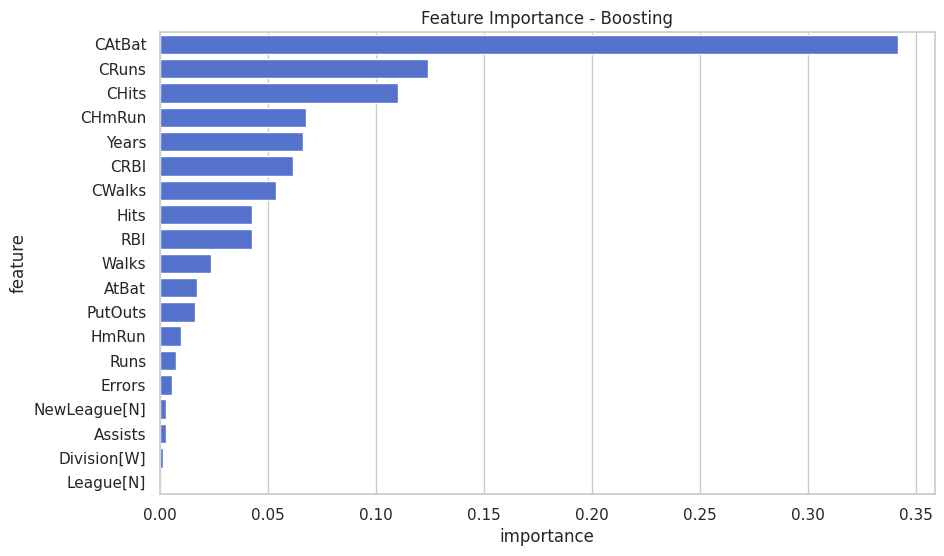

In [109]:
df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": boosted.feature_importances_
})

df_imp = df_imp.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp, x="importance", y="feature", color="royalblue")

plt.title("Feature Importance - Boosting")
plt.show()

## (g) Now apply bagging to the training set. What is the test set MSE for this approach?

In [110]:
rf_hitters = RandomForestRegressor(random_state=42,
                                   max_features=X_train.shape[1]).fit(X_train, y_train)

y_hat_rf = rf_hitters.predict(X_test)

np.mean((y_test - y_hat_rf)**2)

np.float64(0.24084972486767225)